In [ ]:
import sys
!{sys.executable} -m pip install geopandas

In [1]:
import pandas as pd
import geopandas as gpd
print(gpd.__version__)

1.1.3


## Data
https://geodata.colorado.gov/datasets/0b26c8161c1e4597816b107f0dba0d15_0/explore?location=39.934750%2C-102.798471%2C6

https://demography.dola.colorado.gov/assets/html/county.html

In [46]:
loc_df = pd.read_csv("data/Colorado_Polling_Locations_2025.csv")
loc_df.head()

,X,Y,county,site_type,site_availability,site_info,name,address_line1,address_line2,address_city,...,sh_10_27,sh_10_28,sh_10_29,sh_10_30,sh_10_31,sh_11_1,sh_11_2,sh_11_3,sh_11_4,OBJECTID
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,10/14/2025 to 11/04/2025,24-hour dropbox,Elbert County Elections Office,440 Comanche Street,NaN,Kiowa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,10/14/2025 to 11/04/2025,24-hour dropbox,Elizabeth Town Hall,151 S Banner Street,NaN,Elizabeth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,10/14/2025 to 11/04/2025,24-hour dropbox,Elbert County Road & Bridge,41082 Firehouse Street,NaN,Parker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,-1.171530e+07,4.642090e+06,Fremont,early vote,10/27/2025 to 11/03/2025,9:00AM-5:00PM M-F,Garden Park,201 N 6th St,NaN,Canon City,...,NaN,NaN,NaN,NaN,NaN,9:00AM-1:00PM,NaN,NaN,NaN,4
4,-1.171530e+07,4.642090e+06,Fremont,polling location,11/04/2025,7:00AM-7:00PM Election Day,Garden Park,201 N 6th St,NaN,Canon City,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


In [47]:
print(loc_df["site_type"].value_counts())
print(loc_df["county"].unique())

site_type
dropbox             435
polling location    150
early vote          147
drop off             28
drop box              2
Polling Location      2
Drop Box              2
Early vote            1
Name: count, dtype: int64
['Elbert' 'Fremont' 'Garfield ' 'GILPIN' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson  County'
 'La Plata County ' 'Lake' 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa'
 'Mineral' 'Moffat' 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park'
 'Phillips' 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt'
 'Saguache' 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller'
 'Washington' 'Weld' 'Yuma ' 'Adams' 'Alamosa' 'Arapahoe' 'Archuleta'
 'Baca' 'Bent' 'Boulder' 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek'
 'Conejos' 'Costilla' 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores'
 'Douglas' 'Eagle' 'El Paso']


In [48]:
# Drop unnecessary columns
loc_columns_to_drop = [4,5,6,7,8,9,10,11,12,13,14,16,17,18,19,20,21,22,23,24,
                       25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42]
                       
loc_df = loc_df.drop(columns=loc_df.columns[loc_columns_to_drop])

# Normalize formatting of site_type entries
loc_df["site_type"] = (loc_df["site_type"].str.strip().str.lower())
site_mapping = {
    "dropbox": "dropbox",
    "drop box": "dropbox",
    "drop off": "dropbox",
    
    "polling location": "polling location",
    
    "early vote": "early vote"
}
loc_df["site_type"] = loc_df["site_type"].replace(site_mapping)

# Rename county "GILPIN" to "Gilpin" and remove county from "Kit Carson  County" to match formatting 
county_mapping = {
    "Garfield ": "Garfield",
    "Yuma ": "Yuma",
    "GILPIN": "Gilpin",
    "Kit Carson  County": "Kit Carson",
    "La Plata County ": "La Plata"
}
    
loc_df["county"] = loc_df["county"].replace(county_mapping)

loc_df.head()

,X,Y,county,site_type,geocoded_address
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,"440 Comanche St, Kiowa, Colorado, 80117"
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,"151 S Banner St, Elizabeth, Colorado, 80107"
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,"41082 Firehouse St, Parker, Colorado, 80138"
3,-1.171530e+07,4.642090e+06,Fremont,early vote,"201 N 6th St, Canon City, Colorado, 81212"
4,-1.171530e+07,4.642090e+06,Fremont,polling location,"201 N 6th St, Canon City, Colorado, 81212"


In [49]:
print(loc_df["site_type"].value_counts())
print(loc_df["county"].unique())

site_type
dropbox             467
polling location    152
early vote          148
Name: count, dtype: int64
['Elbert' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'La Plata' 'Lake'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma' 'Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'El Paso']


In [50]:

pop_df = pd.read_excel("data/CountyRankings.xlsx")
pop_df.head()

,County FIPS,Area,July 2010,July 2020,July 2021,July 2022,July 2023,July 2024,2024 rank
0,0,COLORADO STATE,5050332,5786877,5813551,5850121,5900420,5956729,NaN
1,1,ADAMS COUNTY,443711,520489,523505,528201,535901,543760,5.0
2,3,ALAMOSA COUNTY,15474,16373,16577,16593,16650,16632,30.0
3,5,ARAPAHOE COUNTY,574819,655288,656858,658069,661564,666557,3.0
4,7,ARCHULETA COUNTY,12060,13429,13815,13993,14182,14137,34.0


In [51]:
# drop first row which is total population of the state
pop_df = pop_df.iloc[1:]

# drop columns with counts other than most recent July 2024
pop_columns_to_drop = [0,2,3,4,5,6,8]
pop_df = pop_df.drop(columns=pop_df.columns[pop_columns_to_drop])

# Rename Area 'county' 
pop_df = pop_df.rename(columns={'Area': 'county', 'July 2024': 'population'})

# Remove 'COUNTY' from county entries to match datasets
pop_df['county'] = pop_df['county'].str.replace(' COUNTY', '')

# Convert county entries to all lowercase except for first letter to match datasets
pop_df['county'] = pop_df['county'].str.title()

pop_df.head()

,county,population
1,Adams,543760
2,Alamosa,16632
3,Arapahoe,666557
4,Archuleta,14137
5,Baca,3398


In [52]:
print(pop_df.isnull().sum())
print(pop_df['county'].unique())

county        0
population    0
dtype: int64
['Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'Elbert'
 'El Paso' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'Lake' 'La Plata'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma']


In [53]:
pop_loc_df = pd.merge(loc_df, pop_df, on='county', how='outer')
pop_loc_df.head()

,X,Y,county,site_type,geocoded_address,population
0,-1.167360e+07,4.829974e+06,Adams,early vote,"2390 N Havana St, Aurora, Colorado, 80010",543760
1,-1.167360e+07,4.829974e+06,Adams,polling location,"2390 N Havana St, Aurora, Colorado, 80010",543760
2,-1.167116e+07,4.829307e+06,Adams,early vote,"12348 E Montview Blvd, Aurora, Colorado, 80045",543760
3,-1.167116e+07,4.829307e+06,Adams,polling location,"12348 E Montview Blvd, Aurora, Colorado, 80045",543760
4,-1.167116e+07,4.829307e+06,Adams,dropbox,"12348 E Montview Blvd, Aurora, Colorado, 80045",543760


In [54]:
print(pop_loc_df.isnull().sum())
print(pop_loc_df['county'].unique())

X                   0
Y                   0
county              0
site_type           0
geocoded_address    0
population          0
dtype: int64
['Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'El Paso'
 'Elbert' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'La Plata' 'Lake'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma']


In [55]:
# Plot Colorado voting stations
gdf = gpd.GeoDataFrame(
    pop_loc_df,
    geometry=gpd.points_from_xy(pop_loc_df["X"], pop_loc_df["Y"]),
    crs="EPSG:3857"
)

# Convert to lat/lon for mapping
gdf = gdf.to_crs(epsg=4326)

gdf.head()

,X,Y,county,site_type,geocoded_address,population,geometry
0,-1.167360e+07,4.829974e+06,Adams,early vote,"2390 N Havana St, Aurora, Colorado, 80010",543760,POINT (-104.86573 39.75203)
1,-1.167360e+07,4.829974e+06,Adams,polling location,"2390 N Havana St, Aurora, Colorado, 80010",543760,POINT (-104.86573 39.75203)
2,-1.167116e+07,4.829307e+06,Adams,early vote,"12348 E Montview Blvd, Aurora, Colorado, 80045",543760,POINT (-104.84384 39.74743)
3,-1.167116e+07,4.829307e+06,Adams,polling location,"12348 E Montview Blvd, Aurora, Colorado, 80045",543760,POINT (-104.84384 39.74743)
4,-1.167116e+07,4.829307e+06,Adams,dropbox,"12348 E Montview Blvd, Aurora, Colorado, 80045",543760,POINT (-104.84384 39.74743)


<Axes: >

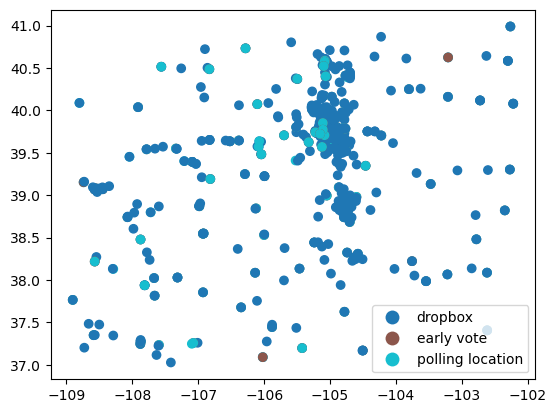

In [56]:
gdf.plot(column="site_type", legend=True)


In [ ]:
gdf["site_type"].value_counts()

In [57]:
gdf["county"].nunique()

64

In [58]:
gdf.isnull().sum()


X                   0
Y                   0
county              0
site_type           0
geocoded_address    0
population          0
geometry            0
dtype: int64